# Comparación entre las tres frecuencias de muestreo
**Óptica y Ondas / UTEC 2026-II**

La guía (sección 3.3) pide tres mediciones, una por cada frecuencia de muestreo.
Este notebook procesa **las cinco corridas válidas** de una sola pasada y produce
la tabla de resultados con su dispersión.

Esto es el **tratamiento estadístico** que pide la rúbrica: no se puede hacer con
una sola corrida.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

COLUMNAS = ["t", "x", "v", "a", "theta", "omega", "alpha"]

CORRIDAS = {
    "10Hz-c1": "biela-manivela-10Hz-08-09-2026-c1.txt",
    "10Hz-c2": "biela-manivela-10Hz-08-09-2026-c2.txt",
    "20Hz-c1": "biela-manivela-20Hz-08-09-2026-c1.txt",
    "20Hz-c2": "biela-manivela-20Hz-08-09-2026-c2.txt",
    "30Hz-c1": "biela-manivela-30Hz-08-09-2026-c1.txt",   # DESCARTADA: ver data/NOTAS.md
    "30Hz-c2": "biela-manivela-30Hz-08-09-2026-c2.txt",
}
VALIDAS = ["10Hz-c1", "10Hz-c2", "20Hz-c1", "20Hz-c2", "30Hz-c2"]

# Ventanas de analisis (identicas a las de los notebooks 01 y 02)
VENTANA = {"10Hz-c1": (1.0, None), "10Hz-c2": (1.0, None), "20Hz-c1": (1.0, None),
           "20Hz-c2": (1.0, 11.1), "30Hz-c2": (1.2, None)}

L_BIELA = 0.36

def dir_datos():
    for c in [Path("../data/raw"), Path("data/raw"), Path(".")]:
        if (c / CORRIDAS["10Hz-c2"]).exists():
            return c
    raise FileNotFoundError("No encuentro data/raw.")

DIR_FIG = Path("../figuras") if Path("../figuras").exists() else Path("figuras")
DIR_FIG.mkdir(exist_ok=True)

def cargar(corrida):
    d = np.genfromtxt(dir_datos() / CORRIDAS[corrida],
                      skip_header=7, encoding="utf-8-sig")
    d = d[~np.isnan(d).any(axis=1)]
    return {c: d[:, i] for i, c in enumerate(COLUMNAS)}

def R2(y, yf):
    return 1 - np.sum((y - yf)**2) / np.sum((y - y.mean())**2)

print(f"datos en: {dir_datos()}")

datos en: ..\data\raw


## 1. Procesar las cinco corridas

In [2]:
filas = []

for k in VALIDAS:
    D = cargar(k)
    t0, t1 = VENTANA[k]
    i0 = int(np.searchsorted(D["t"], t0))
    iF = len(D["t"]) if t1 is None else int(np.searchsorted(D["t"], t1))

    # cortar en numero entero de vueltas
    th_rel = np.abs(D["theta"][:iF] - D["theta"][i0])
    n_v = int(th_rel[-1] // (2*np.pi))
    i1 = int(np.argmin(np.abs(th_rel - n_v*2*np.pi)))

    t  = D["t"][i0:i1+1];     x  = D["x"][i0:i1+1]
    a  = D["a"][i0:i1+1];     th = D["theta"][i0:i1+1]
    om = D["omega"][i0:i1+1]; al = D["alpha"][i0:i1+1]

    dt = np.median(np.diff(t)); N = len(t); T = N*dt

    # --- geometria: ajuste de x(theta) con dos armonicos ---
    M = np.c_[np.ones_like(th), np.cos(th), np.sin(th),
              np.cos(2*th), np.sin(2*th)]
    c, *_ = np.linalg.lstsq(M, x, rcond=None)
    r_aj = np.hypot(c[1], c[2])
    B_aj = np.hypot(c[3], c[4])
    res_mas = x - M[:, :3] @ np.linalg.lstsq(M[:, :3], x, rcond=None)[0]
    res_2ar = x - M @ c

    # --- cinematica angular ---
    om_m, om_s = np.abs(om).mean(), np.abs(om).std()

    # --- espectro de la aceleracion ---
    a_ac = a - a.mean()
    Y = np.fft.rfft(a_ac); frec = np.fft.rfftfreq(N, dt)
    amp = 2/N*np.abs(Y)
    k1 = 1 + int(np.argmax(amp[1:]))
    banda = (frec > 1.5*frec[k1]) & (frec < 2.5*frec[k1])
    k2 = int(np.where(banda)[0][np.argmax(amp[banda])])

    # --- contaminacion por giro no uniforme ---
    dM  = np.c_[np.zeros_like(th), -np.sin(th), np.cos(th),
                -2*np.sin(2*th), 2*np.cos(2*th)]
    d2M = np.c_[np.zeros_like(th), -np.cos(th), -np.sin(th),
                -4*np.cos(2*th), -4*np.sin(2*th)]
    fp, fpp = dM @ c, d2M @ c
    amp_2do = 4*B_aj*(om**2).mean()
    amp_alf = np.std(fp*al)*np.sqrt(2)

    filas.append({
        "corrida": k,
        "fs (Hz)": round(1/dt),
        "vueltas": n_v,
        "N": N,
        "T (s)": round(T, 2),
        "r (cm)": 100*r_aj,
        "B (cm)": 100*B_aj,
        "B teor (cm)": 100*r_aj**2/(4*L_BIELA),
        "w medio": om_m,
        "desv w (%)": 100*om_s/om_m,
        "f1 (Hz)": frec[k1],
        "f2/f1": frec[k2]/frec[k1],
        "A2/A1 acel": 4*B_aj/r_aj,
        "R2 x(th) MAS": R2(x, x - res_mas),
        "R2 x(th) +2ar": R2(x, x - res_2ar),
        "rms MAS (mm)": 1000*res_mas.std(),
        "rms +2ar (mm)": 1000*res_2ar.std(),
        "contam/senal": amp_alf/amp_2do,
    })

tabla = pd.DataFrame(filas).set_index("corrida")
pd.set_option("display.width", 200, "display.max_columns", 30)
tabla.round(3)

,fs (Hz),vueltas,N,T (s),r (cm),B (cm),B teor (cm),w medio,desv w (%),f1 (Hz),f2/f1,A2/A1 acel,R2 x(th) MAS,R2 x(th) +2ar,rms MAS (mm),rms +2ar (mm),contam/senal
corrida,,,,,,,,,,,,,,,,,
10Hz-c1,10,5,136,13.60,11.042,0.691,0.847,2.325,24.116,0.368,2.4,0.250,0.995,0.999,5.447,2.258,1.160
10Hz-c2,10,5,134,13.40,10.845,0.648,0.817,2.369,16.045,0.373,2.2,0.239,0.996,1.000,4.843,1.448,0.801
20Hz-c1,20,5,280,14.00,10.995,0.750,0.840,2.249,25.452,0.357,2.2,0.273,0.993,0.997,6.947,4.418,1.665
20Hz-c2,20,3,166,8.30,10.568,0.583,0.776,2.279,17.833,0.361,2.0,0.221,0.993,0.997,6.007,4.355,1.326
30Hz-c2,30,4,356,11.87,10.571,0.493,0.776,2.124,14.596,0.337,2.0,0.187,0.993,0.995,6.335,5.305,1.805


## 2. Resultado principal: el radio de la manivela

r = 10.80 ± 0.23 cm      (n = 5 corridas, 3 frecuencias)
  error estandar de la media : 0.10 cm
  dispersion relativa        : 2.1 %
  medido con regla           : 12.5 cm

r/L = 0.300   OK, < 1/3


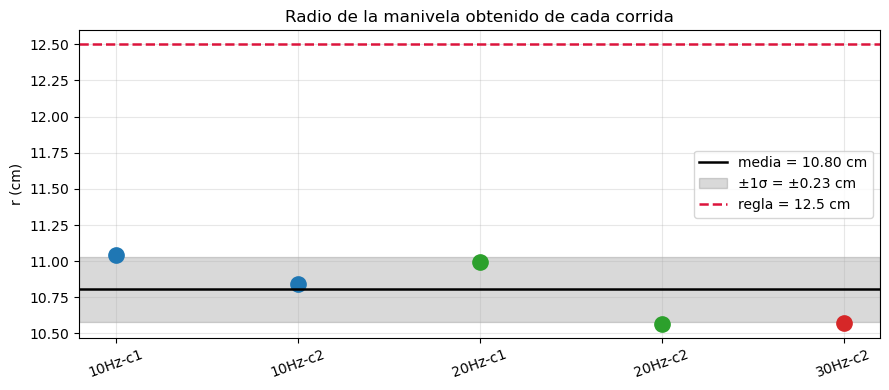

In [3]:
r = tabla["r (cm)"].values
r_m, r_s = r.mean(), r.std(ddof=1)

print(f"r = {r_m:.2f} ± {r_s:.2f} cm      (n = {len(r)} corridas, 3 frecuencias)")
print(f"  error estandar de la media : {r_s/np.sqrt(len(r)):.2f} cm")
print(f"  dispersion relativa        : {100*r_s/r_m:.1f} %")
print(f"  medido con regla           : 12.5 cm")
print()
print(f"r/L = {r_m/100/L_BIELA:.3f}   "
      f"{'OK, < 1/3' if r_m/100/L_BIELA < 1/3 else 'ATENCION: > 1/3'}")

fig, ax = plt.subplots(figsize=(9, 4))
col = {10: "tab:blue", 20: "tab:green", 30: "tab:red"}
for i, (k, f) in enumerate(zip(tabla.index, tabla["fs (Hz)"])):
    ax.plot(i, tabla.loc[k, "r (cm)"], "o", ms=11, color=col[f])
ax.axhline(r_m, color="k", lw=1.8, label=f"media = {r_m:.2f} cm")
ax.axhspan(r_m-r_s, r_m+r_s, alpha=.15, color="k", label=f"±1σ = ±{r_s:.2f} cm")
ax.axhline(12.5, color="crimson", ls="--", lw=1.8, label="regla = 12.5 cm")
ax.set_xticks(range(len(tabla))); ax.set_xticklabels(tabla.index, rotation=20)
ax.set_ylabel("r (cm)"); ax.legend()
ax.set_title("Radio de la manivela obtenido de cada corrida")
plt.tight_layout()
plt.savefig(DIR_FIG/"09_comparacion_r.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Efecto de la frecuencia de muestreo

Logger Pro obtiene la aceleración derivando numéricamente la posición dos veces.
Al reducir Δt el ruido de cuantización del sensor se amplifica como 1/Δt², así que
**más muestras por segundo no significa mejor señal de aceleración**.

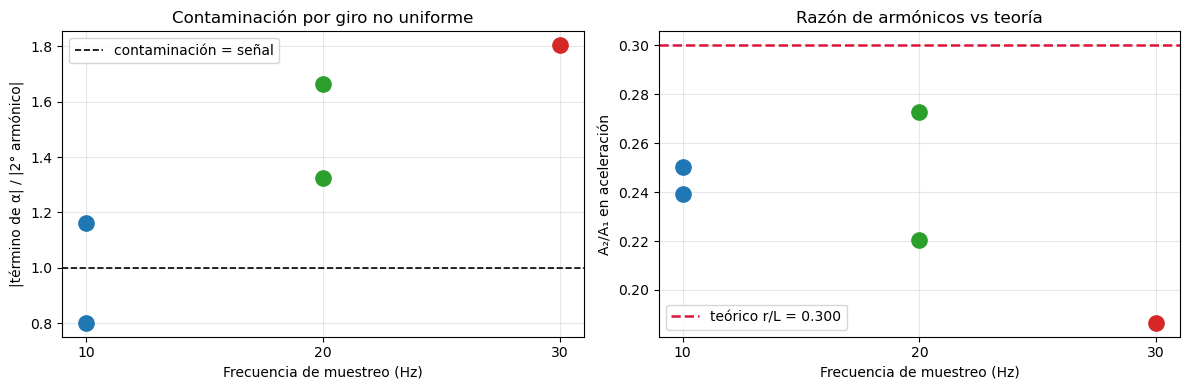

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for k in tabla.index:
    f = tabla.loc[k, "fs (Hz)"]
    ax[0].plot(f, tabla.loc[k, "contam/senal"], "o", ms=11, color=col[f])
    ax[1].plot(f, tabla.loc[k, "A2/A1 acel"], "o", ms=11, color=col[f])

ax[0].axhline(1, ls="--", c="k", lw=1.2,
              label="contaminación = señal")
ax[0].set_xlabel("Frecuencia de muestreo (Hz)")
ax[0].set_ylabel("|término de α| / |2° armónico|")
ax[0].set_title("Contaminación por giro no uniforme"); ax[0].legend()

ax[1].axhline(r_m/100/L_BIELA, ls="--", c="crimson", lw=1.8,
              label=f"teórico r/L = {r_m/100/L_BIELA:.3f}")
ax[1].set_xlabel("Frecuencia de muestreo (Hz)")
ax[1].set_ylabel("A₂/A₁ en aceleración")
ax[1].set_title("Razón de armónicos vs teoría"); ax[1].legend()

for a_ in ax:
    a_.set_xticks([10, 20, 30])
plt.tight_layout()
plt.savefig(DIR_FIG/"10_efecto_fs.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Exportar la tabla para el documento

In [5]:
DIR_DOC = Path("../docs") if Path("../docs").exists() else Path("docs")
DIR_DOC.mkdir(exist_ok=True)

resumen = tabla[["fs (Hz)", "vueltas", "N", "r (cm)", "B (cm)", "B teor (cm)",
                 "desv w (%)", "f1 (Hz)", "f2/f1", "A2/A1 acel",
                 "rms MAS (mm)", "rms +2ar (mm)", "contam/senal"]].round(3)

resumen.to_csv(DIR_DOC/"tabla_resumen.csv")
with open(DIR_DOC/"tabla_resumen.md", "w", encoding="utf-8") as fh:
    fh.write("# Tabla resumen de las cinco corridas válidas\n\n")
    fh.write(resumen.to_markdown())
    fh.write(f"\n\n**r = {r_m:.2f} ± {r_s:.2f} cm** "
             f"(n={len(r)}, dispersión {100*r_s/r_m:.1f} %). "
             f"Medido con regla: 12.5 cm.\n")

print(f"escritos: {DIR_DOC/'tabla_resumen.csv'}")
print(f"          {DIR_DOC/'tabla_resumen.md'}")
print()
print(resumen.to_markdown())

escritos: docs\tabla_resumen.csv
          docs\tabla_resumen.md

| corrida   |   fs (Hz) |   vueltas |   N |   r (cm) |   B (cm) |   B teor (cm) |   desv w (%) |   f1 (Hz) |   f2/f1 |   A2/A1 acel |   rms MAS (mm) |   rms +2ar (mm) |   contam/senal |
|:----------|----------:|----------:|----:|---------:|---------:|--------------:|-------------:|----------:|--------:|-------------:|---------------:|----------------:|---------------:|
| 10Hz-c1   |        10 |         5 | 136 |   11.042 |    0.691 |         0.847 |       24.116 |     0.368 |     2.4 |        0.25  |          5.447 |           2.258 |          1.16  |
| 10Hz-c2   |        10 |         5 | 134 |   10.845 |    0.648 |         0.817 |       16.045 |     0.373 |     2.2 |        0.239 |          4.843 |           1.448 |          0.801 |
| 20Hz-c1   |        20 |         5 | 280 |   10.995 |    0.75  |         0.84  |       25.452 |     0.357 |     2.2 |        0.273 |          6.947 |           4.418 |          1.665 |
| 20

## 5. Qué decir en el video con esta tabla

1. **r = valor ± dispersión** de cinco corridas independientes a tres frecuencias
   distintas. Esa es la medición de precisión del laboratorio, y es mejor que la regla.
2. **La geometría es reproducible, el espectro de la aceleración no.** r varía ~2%
   entre corridas; A₂/A₁ medido en la aceleración varía mucho más. La razón está en la
   columna `contam/senal`: el término f'(θ)·α es del mismo orden que el segundo armónico.
3. **Subir la frecuencia de muestreo no mejoró la aceleración.** El ruido de la doble
   derivada numérica crece como 1/Δt². Es un resultado propio, y solo se puede afirmar
   porque se tomaron las tres frecuencias.